# CVRIE — Supervised Learning

## Import Required Libraries

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

from PIL import Image
from random import randint
from enum import Enum

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    mean_squared_error,
    ConfusionMatrixDisplay,
    f1_score
)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

## Global Parameters

The project uses two datasets containing the same class folders:

- `dataset/` main dataset used to train the models
- `comp_dataset/` comparison dataset used to evaluate how well the models generalize outside the training source

To avoid making the notebook too slow after augmentation, the training dataset is voluntarily limited. The goal is to keep enough data to train the models, while avoiding very long execution times during the presentation.

In [4]:
RANDOM_STATE = 42
IMAGE_SIZE = (128, 128)

TRAIN_DATASET_FOLDER = 'Dataset/dataset_a/'
COMP_DATASET_FOLDER = 'Dataset/dataset_b/'

MAX_IMAGES_PER_LABEL_TRAIN = 1000
MAX_TOTAL_TRAIN_IMAGES_AFTER_AUGMENTATION = 10000
AUGMENTATION_ANGLES = [-15, -10, -5, 5, 10, 15]

# Load Dataset and Apply Preprocessing

- the **training dataset** is limited to approximately 1000 images per class to keep the notebook light
- the **comparison dataset** is loaded separately to keep an external reference for evaluation.

In [5]:
def recover_images(dataset_folder, max_images_per_label=None):
    all_images = []
    label_images = []
    original_images = []
    grayscale_images = []
    resize_images = []

    for label in os.listdir(dataset_folder):
        path_folder = os.path.join(dataset_folder, label)

        if os.path.isdir(path_folder) == False:
            continue

        files = []

        for file in os.listdir(path_folder):
            if file.endswith(".jpg"):
                files.append(file)

        if max_images_per_label is not None:
            files = files[:max_images_per_label]

        for file in files:
            image_path = os.path.join(path_folder, file)

            image = Image.open(image_path).convert("RGB")
            image_grayscale = image.convert("L")
            image_resize = image_grayscale.resize(IMAGE_SIZE)
            image_array = np.array(image_resize)

            original_images.append(np.array(image))
            grayscale_images.append(np.array(image_grayscale))
            resize_images.append(np.array(image_resize))
            all_images.append(image_array)
            label_images.append(label)

    return (original_images, grayscale_images, resize_images, np.array(all_images), np.array(label_images))

train_original_images, train_grayscale_images, train_resize_images, train_all_images, train_label_images = recover_images(TRAIN_DATASET_FOLDER, max_images_per_label = MAX_IMAGES_PER_LABEL_TRAIN)
comp_original_images, comp_grayscale_images, comp_resize_images, comp_all_images, comp_label_images = recover_images(COMP_DATASET_FOLDER)

## Dataset Overview

This step verify that both datasets were loaded correctly and that the preprocessing produced coherent image arrays.

In [6]:
print("TRAIN DATASET")
print(f"Total number of images : {len(train_all_images)}")
print(f"Shape of image array : {train_all_images.shape}")
print(f"Unique labels : {np.unique(train_label_images)}\n")

print("COMPARISON DATASET")
print(f"Total number of images : {len(comp_all_images)}")
print(f"Shape of image array : {comp_all_images.shape}")
print(f"Unique labels : {np.unique(comp_label_images)}")

TRAIN DATASET
Total number of images : 4000
Shape of image array : (4000, 128, 128)
Unique labels : ['MildDemented' 'ModerateDemented' 'NonDemented' 'VeryMildDemented']

COMPARISON DATASET
Total number of images : 6400
Shape of image array : (6400, 128, 128)
Unique labels : ['MildDemented' 'ModerateDemented' 'NonDemented' 'VeryMildDemented']


## Visualization of Random Images

This visual show that the two datasets differ in contrast, orientation, scale, or visual style.

This matters because it show that the comparison dataset is visually different from the training one.

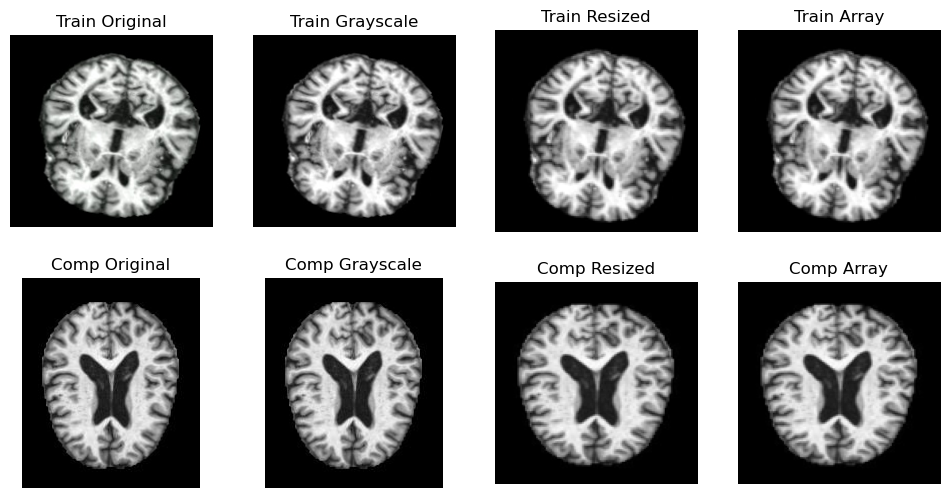

In [30]:
train_index = randint(0, len(train_all_images) - 1)
comp_index = randint(0, len(comp_all_images) - 1)

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

axes[0, 0].imshow(train_original_images[train_index])
axes[0, 0].set_title("Train Original")
axes[0, 1].imshow(train_grayscale_images[train_index], cmap="gray")
axes[0, 1].set_title("Train Grayscale")
axes[0, 2].imshow(train_resize_images[train_index], cmap="gray")
axes[0, 2].set_title("Train Resized")
axes[0, 3].imshow(train_all_images[train_index], cmap="gray")
axes[0, 3].set_title("Train Array")

axes[1, 0].imshow(comp_original_images[comp_index])
axes[1, 0].set_title("Comp Original")
axes[1, 1].imshow(comp_grayscale_images[comp_index], cmap="gray")
axes[1, 1].set_title("Comp Grayscale")
axes[1, 2].imshow(comp_resize_images[comp_index], cmap="gray")
axes[1, 2].set_title("Comp Resized")
axes[1, 3].imshow(comp_all_images[comp_index], cmap="gray")
axes[1, 3].set_title("Comp Array")

for ax in axes.flat:
    ax.axis("off")

plt.show()

## Normalization

The same normalization is applied to both datasets so model inputs can be comparable.

In [31]:
print("TRAIN DATASET - before normalization")
print(f"min : {train_all_images.min()}\nmax : {train_all_images.max()}\nmean : {train_all_images.mean()}")

print("\nCOMPARISON DATASET - before normalization")
print(f"min : {comp_all_images.min()}\nmax : {comp_all_images.max()}\nmean : {comp_all_images.mean()}")

train_normalized_images = train_all_images / 255.0
comp_normalized_images = comp_all_images / 255.0

print("\nTRAIN DATASET - after normalization")
print(f"min : {train_normalized_images.min()}\nmax : {train_normalized_images.max()}\nmean : {train_normalized_images.mean()}")

print("\nCOMPARISON DATASET - after normalization")
print(f"min : {comp_normalized_images.min()}\nmax : {comp_normalized_images.max()}\nmean : {comp_normalized_images.mean()}")

TRAIN DATASET - before normalization
min : 0
max : 255
mean : 75.38699545288085

COMPARISON DATASET - before normalization
min : 0
max : 255
mean : 71.83939675331116

TRAIN DATASET - after normalization
min : 0.0
max : 1.0
mean : 0.29563527628580644

COMPARISON DATASET - after normalization
min : 0.0
max : 1.0
mean : 0.28172312452278886


### Interpretation of the Results

At this point, both datasets have gone through the same preprocessing steps:
grayscale conversion, resizing, and normalization.

# Label Encoding

In [32]:
class Label(Enum):
    Unknown = -1
    NonDemented = 0
    ModerateDemented = 1
    MildDemented = 2
    VeryMildDemented = 3

def convert_label_to_value(labels):
    list_enum = []

    for label in labels:
        match label:
            case "NonDemented":
                list_enum.append(Label.NonDemented.value)
            case "ModerateDemented":
                list_enum.append(Label.ModerateDemented.value)
            case "MildDemented":
                list_enum.append(Label.MildDemented.value)
            case "VeryMildDemented":
                list_enum.append(Label.VeryMildDemented.value)
            case _:
                list_enum.append(Label.Unknown.value)
    return list_enum

print("\nBefore encoding :")
print(f"\tTraining labels before encoding : {train_label_images[0]}")
print(f"\tComparison labels : {comp_label_images[0]}")

train_label_enum = convert_label_to_value(train_label_images)
comp_label_enum = convert_label_to_value(comp_label_images)

print("\nAfter encoding :")
print(f"\tTraining labels : {train_label_enum[0]}")
print(f"\tComparison labels : {comp_label_enum[0]}")


Before encoding :
	Training labels before encoding : MildDemented
	Comparison labels : MildDemented

After encoding :
	Training labels : 2
	Comparison labels : 2


### Interpretation of the Results

This step transforms textual folder names into numerical class labels that can be used by the machine learning models.
The same mapping is kept for both datasets to ensure full consistency.

## Split main Dataset

We keep one part for training and one part for testing. This lets us check if the model really generalizes or if it only learns the training images.

In [33]:
X_train_images, X_test_images, Y_train_labels, Y_test_labels = train_test_split(train_normalized_images, train_label_enum, test_size=0.3, random_state=RANDOM_STATE, stratify=train_label_enum)

print("Split on main dataset :")
print(f"Training images : {len(X_train_images)}")
print(f"Test images : {len(X_test_images)}")

Split on main dataset :
Training images : 2800
Test images : 1200


## Data Augmentation

The training set can be enriched to improve robustness

To avoid very long runtimes, augmentation is also limit to stays below **10,000** images.
We use a small rotations transformation to introduce more realistic variation.

In [34]:
def rotate_image(image, angle):
    image_255 = image * 255
    image_uint8 = image_255.astype(np.uint8)

    pil_image = Image.fromarray(image_uint8)
    rotated_image = pil_image.rotate(angle)

    rotated_array = np.array(rotated_image)
    rotated_array = rotated_array / 255.0

    return rotated_array

def augment_images(images, labels, max_total_images, rotation_angles, random_state=RANDOM_STATE):
    random_generator = np.random.default_rng(random_state)

    augmented_images = []
    augmented_labels = []

    for image in images:
        augmented_images.append(image)

    for label in labels:
        augmented_labels.append(label)

    current_image_count = len(images)
    additional_images_needed = max_total_images - current_image_count

    if additional_images_needed <= 0:
        return np.array(augmented_images), np.array(augmented_labels)

    chosen_indexes = random_generator.choice(len(images), size = additional_images_needed, replace=True)

    for index in chosen_indexes:
        chosen_image = images[index]
        chosen_label = labels[index]

        chosen_angle = random_generator.choice(rotation_angles)
        chosen_angle = int(chosen_angle)

        rotated_image = rotate_image(chosen_image, chosen_angle)

        augmented_images.append(rotated_image)
        augmented_labels.append(chosen_label)

    return np.array(augmented_images), np.array(augmented_labels)

train_augmented_images, train_augmented_labels = augment_images(X_train_images, Y_train_labels, MAX_TOTAL_TRAIN_IMAGES_AFTER_AUGMENTATION, AUGMENTATION_ANGLES)

print("Before augmentation :")
print(f"\tX_train_images : {len(X_train_images)}")
print(f"\tX_test_images : {len(X_test_images)}")

print("\nAfter augmentation :")
print(f"\ttrain_augmented_images : {len(train_augmented_images)}")

Before augmentation :
	X_train_images : 2800
	X_test_images : 1200

After augmentation :
	train_augmented_images : 10000


### Interpretation of the Results

The objective here is not to artificially explode the dataset size, but to create a controlled increase in training diversity.

This is a reasonable compromise for the project
- enough augmentation to make training robust
- not too much augmentation, so that model execution time stays correct

### Display a Random Image and Some Augmented Versions

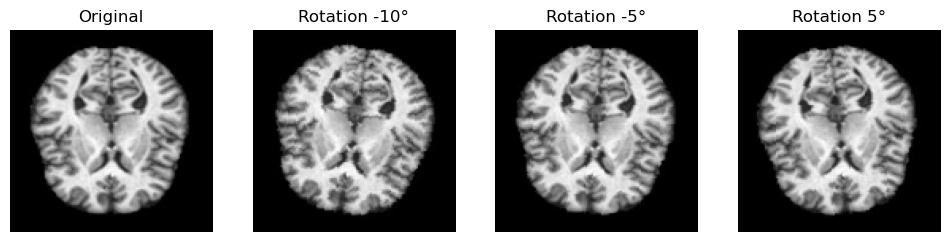

In [35]:
index = randint(0, len(X_train_images) - 1)
chosen_image = X_train_images[index]

fig, axes = plt.subplots(1, 4, figsize=(12, 4))

axes[0].imshow(chosen_image, cmap="gray")
axes[0].set_title("Original")

for i, angle in enumerate(AUGMENTATION_ANGLES[1:4], start=1):
    axes[i].imshow(rotate_image(chosen_image, angle), cmap="gray")
    axes[i].set_title(f"Rotation {angle}°")

for ax in axes:
    ax.axis("off")

plt.show()

## Label Distribution

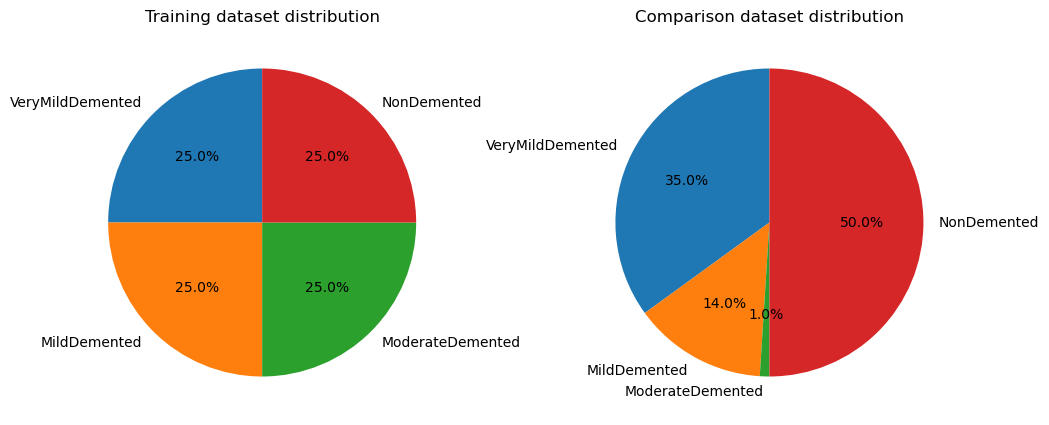

In [36]:
def calculate_average(labels):
    VeryMildDemented = 0
    MildDemented = 0
    ModerateDemented = 0
    NonDemented = 0

    for i in labels:
        match i:
            case 0:
                NonDemented += 1
            case 1:
                ModerateDemented += 1
            case 2:
                MildDemented += 1
            case 3:
                VeryMildDemented += 1

    return VeryMildDemented, MildDemented, ModerateDemented, NonDemented

train_distribution = calculate_average(Y_train_labels)
comp_distribution = calculate_average(comp_label_enum)

labels = ['VeryMildDemented', 'MildDemented', 'ModerateDemented', 'NonDemented']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].pie(train_distribution, labels=labels, autopct='%1.1f%%', startangle=90)
axes[0].set_title('Training dataset distribution')

axes[1].pie(comp_distribution, labels=labels, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Comparison dataset distribution')

plt.show()

### Interpretation of the Results

Checking class distribution is important because imbalanced dataset can affect the learning process and change the interpretation of accuracy.
The first dataset is intentionally equally distributed so, the model does not learn one category more than the others. In contrast, the second comparison dataset has a more realistic distribution of cases, closer to what can be observed in real life.

### Evaluation Visualization

Visualization functions reused for each models.

In [37]:
def show_graph(Y_test, Y_pred):
    counts = pd.Series(Y_test).value_counts()

    NonDemented = counts.get(Label.NonDemented.value, 0)
    ModerateDemented = counts.get(Label.ModerateDemented.value, 0)
    MildDemented = counts.get(Label.MildDemented.value, 0)
    VeryMildDemented = counts.get(Label.VeryMildDemented.value, 0)

    cm = confusion_matrix(Y_test, Y_pred, labels=[Label.NonDemented.value, Label.ModerateDemented.value, Label.MildDemented.value, Label.VeryMildDemented.value])

    correct = np.diag(cm)
    total = cm.sum(axis=1)
    incorrect = total - correct
    accuracy = np.divide(correct, total, out=np.zeros_like(correct, dtype=float), where=total != 0) * 100

    labels = [f"ND ({NonDemented})\n{accuracy[0]:.1f}%", f"MD ({ModerateDemented})\n{accuracy[1]:.1f}%", f"MidD ({MildDemented})\n{accuracy[2]:.1f}%", f"VMidD ({VeryMildDemented})\n{accuracy[3]:.1f}%"]

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    disp = ConfusionMatrixDisplay(cm, display_labels=labels)
    disp.plot(cmap="Greens", colorbar=False, ax=axes[0])
    axes[0].set_title("Confusion Matrix")

    df = pd.DataFrame({'label': labels, 'correct': correct, 'incorrect': incorrect})
    axes[1].set_title("Correct vs Incorrect Predictions")

    df_melt = df.melt(id_vars='label', value_name='Value count', var_name='type')
    sb.barplot(data=df_melt, x='label', y='Value count', hue='type', palette=['Green', 'LightGray'], ax=axes[1])
    plt.show()

def evaluate_overfitting(model, X_train, Y_train, X_test, Y_test, X_comp, Y_comp, model_name):
    Y_train_pred = model.predict(X_train)
    Y_test_pred = model.predict(X_test)
    Y_comp_pred = model.predict(X_comp)

    train_accuracy = accuracy_score(Y_train, Y_train_pred)
    test_accuracy = accuracy_score(Y_test, Y_test_pred)
    comp_accuracy = accuracy_score(Y_comp, Y_comp_pred)

    train_mse = mean_squared_error(Y_train, Y_train_pred)
    test_mse = mean_squared_error(Y_test, Y_test_pred)
    comp_mse = mean_squared_error(Y_comp, Y_comp_pred)

    print(f"\n{model_name} | Accuracy (ideally close to 1) :")
    print(f"Training accuracy : {train_accuracy:.4f}")
    print(f"Internal test accuracy : {test_accuracy:.4f}")
    print(f"Comparison dataset accuracy : {comp_accuracy:.4f}")

    print(f"\n{model_name} | Mean Squared Error (ideally close to 0) :")
    print(f"Training MSE : {train_mse:.4f}")
    print(f"Internal test MSE : {test_mse:.4f}")
    print(f"Comparison dataset MSE : {comp_mse:.4f}")

    internal_gap = train_accuracy - test_accuracy
    external_gap = train_accuracy - comp_accuracy

    print(f"\n{model_name} | Overfitting (ideally close to 0) :")
    print(f"Gap between train and internal test : {internal_gap:.4f}")
    print(f"Gap between train and comparison dataset : {external_gap:.4f}")

    test_macro_f1 = f1_score(Y_test, Y_test_pred, average='macro')
    comp_macro_f1 = f1_score(Y_comp, Y_comp_pred, average='macro')

    print(f"\n{model_name} | F1-score (ideally close to 1) :")
    print(f"Internal test Macro F1 : {test_macro_f1:.4f}")
    print(f"Comparison dataset Macro F1 : {comp_macro_f1:.4f}")

    return Y_test_pred, Y_comp_pred

# Preparing the Data for Model Training

The images are converted into flat numerical vectors so they can be used by classical machine learning models.
We prepare three datasets: 

    -the training set
    -the main dataset test set
    -the comparison dataset

Each image becomes one row, and the target column contains the label to predict.

In [38]:
train_image_array = np.array(train_augmented_images)
train_tab_value_2d = train_image_array.reshape(train_image_array.shape[0], -1)
train_dataframe = pd.DataFrame(train_tab_value_2d).astype("float32")
train_dataframe['TARGET'] = train_augmented_labels

X_train_base = train_dataframe.drop(columns=['TARGET'])
Y_train = train_dataframe['TARGET']


test_image_array = np.array(X_test_images)
test_tab_value_2d = test_image_array.reshape(test_image_array.shape[0], -1)
test_dataframe = pd.DataFrame(test_tab_value_2d).astype("float32")
test_dataframe['TARGET'] = Y_test_labels

X_test_base = test_dataframe.drop(columns=['TARGET'])
Y_test = test_dataframe['TARGET']


comp_image_array = np.array(comp_normalized_images)
comp_tab_value_2d = comp_image_array.reshape(comp_image_array.shape[0], -1)
comp_dataframe = pd.DataFrame(comp_tab_value_2d).astype("float32")
comp_dataframe['TARGET'] = comp_label_enum

X_comp_base = comp_dataframe.drop(columns=['TARGET'])
Y_comp = comp_dataframe['TARGET']

print("Training matrix shape :", X_train_base.shape)
print("Test matrix shape :", X_test_base.shape)
print("Comparison matrix shape :", X_comp_base.shape)

Training matrix shape : (10000, 16384)
Test matrix shape : (1200, 16384)
Comparison matrix shape : (6400, 16384)


# Random Forest

For this project, hyperparameter tuning was performed **beforehand** on a separate exploration phase.
The search code is not repeated here because it considerably slows down the notebook, but the selected parameters are kept below.

# Hyperparameter Tuning with RandomizedSearchCV

The goal of that search was to identify a good balance between:
- model capacity,
- robustness,
- and runtime.

### Summary of the Hyperparameters

- **n_estimators**: number of trees in the forest  
- **bootstrap**: whether each tree is trained on a bootstrap sample  

Selected configuration used in this notebook:
- `n_estimators = 200`
- `bootstrap = False`

## Random Forest Training and Evaluation

In [39]:
random_forest = RandomForestClassifier(bootstrap=False, n_estimators=200, random_state=RANDOM_STATE,)

random_forest.fit(X_train_base, Y_train)

Y_test_pred, Y_comp_pred = evaluate_overfitting(random_forest, X_train_base, Y_train, X_test_base, Y_test, X_comp_base, Y_comp, "Random Forest")


Random Forest | Accuracy (ideally close to 1) :
Training accuracy : 1.0000
Internal test accuracy : 0.5975
Comparison dataset accuracy : 0.6039

Random Forest | Mean Squared Error (ideally close to 0) :
Training MSE : 0.0000
Internal test MSE : 1.5392
Comparison dataset MSE : 1.8077

Random Forest | Overfitting (ideally close to 0) :
Gap between train and internal test : 0.4025
Gap between train and comparison dataset : 0.3961

Random Forest | F1-score (ideally close to 1) :
Internal test Macro F1 : 0.5921
Comparison dataset Macro F1 : 0.5444


## Graphical Visualization

Main dataset test results
Global accuracy : 0.5975


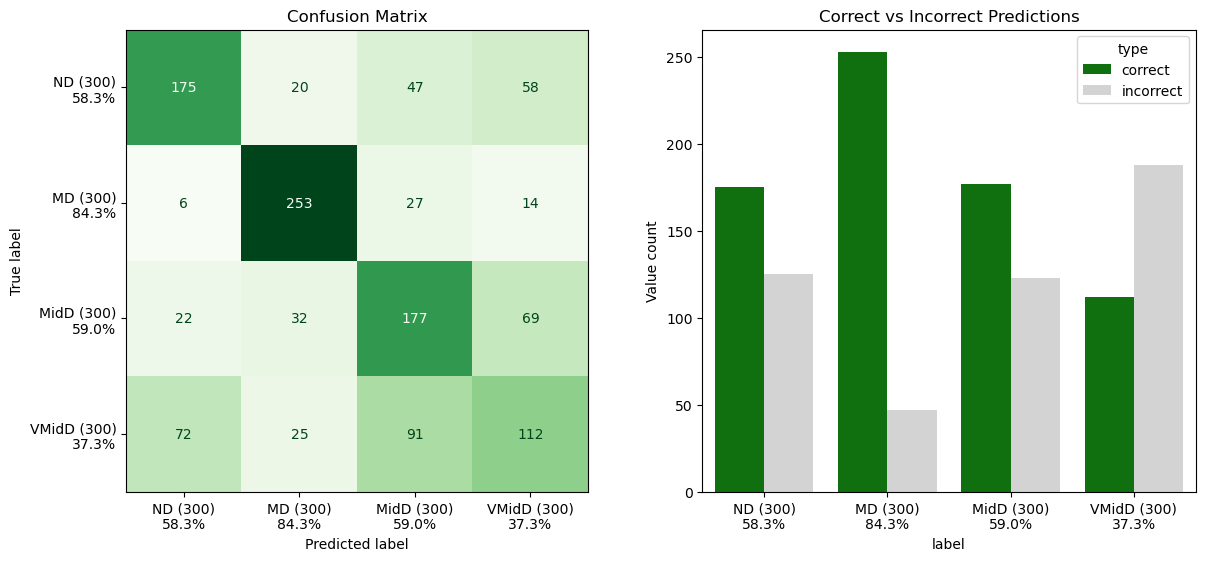

Comparison dataset results
Global accuracy : 0.6039


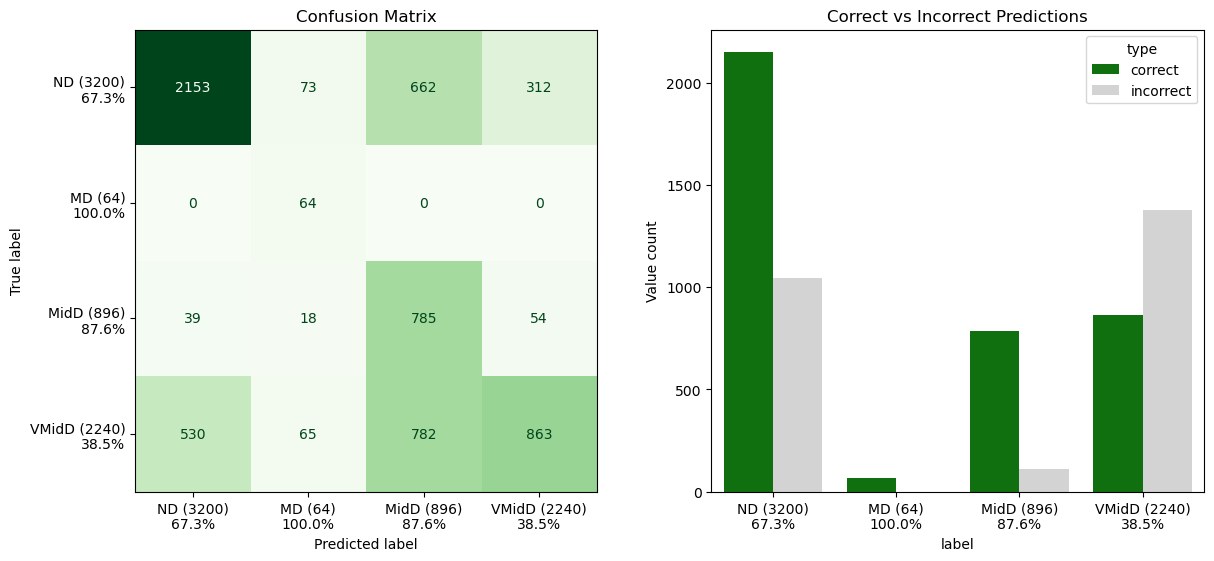

In [40]:
print("Main dataset test results")
print(f"Global accuracy : {accuracy_score(Y_test, Y_test_pred):.4f}")
show_graph(Y_test, Y_test_pred)

print("Comparison dataset results")
print(f"Global accuracy : {accuracy_score(Y_comp, Y_comp_pred):.4f}")
show_graph(Y_comp, Y_comp_pred)

# Linear SVC

## Hyperparameter Tuning for LinearSVC

A tuning phase was also carried out beforehand for LinearSVC.

The search code is intentionally removed from this notebook version to avoid long execution times during `Run All`.

### Selected configuration

- `C = 1`
- `max_iter = 10000`
- `multi_class = 'ovr'`
- `penalty = 'l2'`

## Launch LinearSVC

In [41]:
Scaler = MinMaxScaler()

X_train_scaled = Scaler.fit_transform(X_train_base)
X_test_scaled = Scaler.transform(X_test_base)
X_comp_scaled = Scaler.transform(X_comp_base)

linear_svc = LinearSVC(C=1, max_iter=10000, multi_class='ovr', penalty='l2', random_state=RANDOM_STATE, dual=True)

linear_svc.fit(X_train_scaled, Y_train)

Y_test_pred, Y_comp_pred = evaluate_overfitting(linear_svc, X_train_scaled, Y_train, X_test_scaled, Y_test, X_comp_scaled, Y_comp, "Linear SVC")

/usr/lib/python3/dist-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(



Linear SVC | Accuracy (ideally close to 1) :
Training accuracy : 0.9999
Internal test accuracy : 0.5850
Comparison dataset accuracy : 0.6314

Linear SVC | Mean Squared Error (ideally close to 0) :
Training MSE : 0.0009
Internal test MSE : 1.8333
Comparison dataset MSE : 2.1878

Linear SVC | Overfitting (ideally close to 0) :
Gap between train and internal test : 0.4149
Gap between train and comparison dataset : 0.3685

Linear SVC | F1-score (ideally close to 1) :
Internal test Macro F1 : 0.5860
Comparison dataset Macro F1 : 0.6075


## Graph Visualization

Main dataset test results
Global accuracy : 0.5850


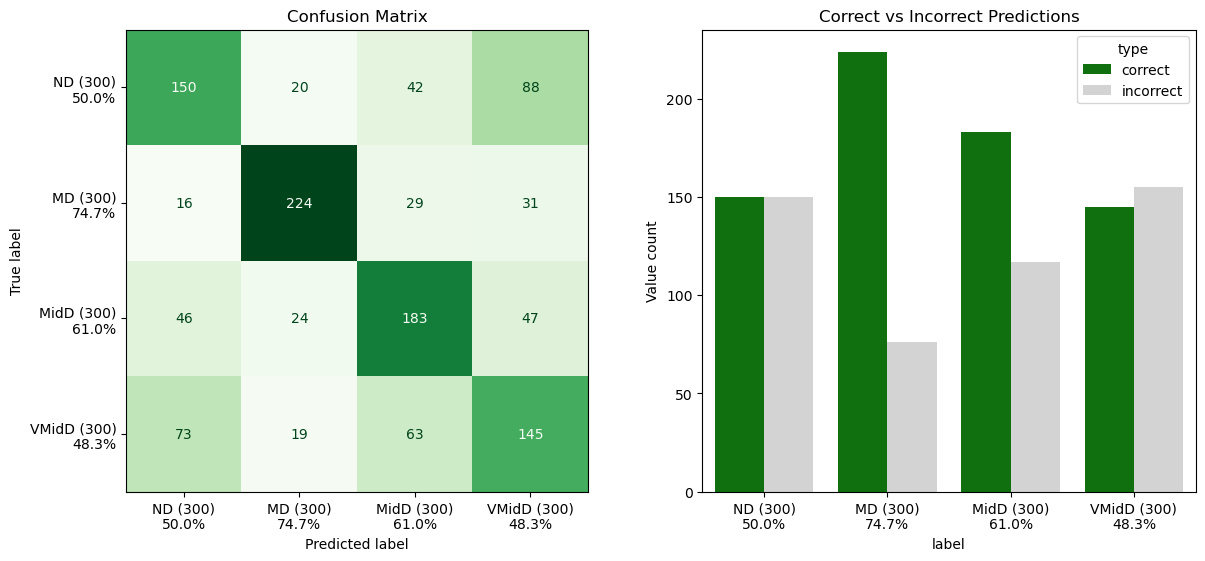

Comparison dataset results
Global accuracy : 0.6314


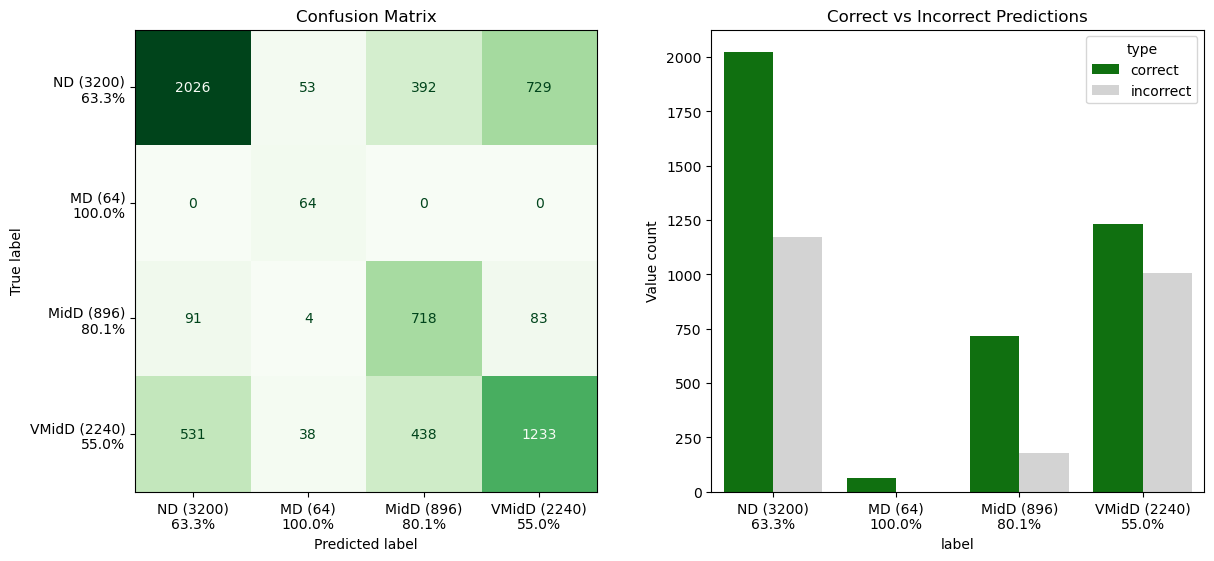

In [42]:
print("Main dataset test results")
print(f"Global accuracy : {accuracy_score(Y_test, Y_test_pred):.4f}")
show_graph(Y_test, Y_test_pred)

print("Comparison dataset results")
print(f"Global accuracy : {accuracy_score(Y_comp, Y_comp_pred):.4f}")
show_graph(Y_comp, Y_comp_pred)

# Gradient Boosting Classifier

Gradient Boosting is another ensemble approach, but unlike Random Forest, it builds trees sequentially to correct previous errors.

## Hyperparameter Tuning for GradientBoostingClassifier

As with the previous models, hyperparameter tuning was done beforehand and is not repeated here.

### Selected configuration

- `learning_rate = 0.2`
- `max_depth = None`
- `max_features = 1`
- `min_samples_split = 5`

# Launch GradientBoostingClassifier

In [43]:
gradient_boosting = GradientBoostingClassifier(learning_rate=0.2, max_depth=None, max_features=1, min_samples_split=5, random_state=RANDOM_STATE)

gradient_boosting.fit(X_train_base, Y_train)

Y_test_pred, Y_comp_pred = evaluate_overfitting(gradient_boosting, X_train_base, Y_train, X_test_base, Y_test, X_comp_base, Y_comp, "Gradient Boosting")


Gradient Boosting | Accuracy (ideally close to 1) :
Training accuracy : 1.0000
Internal test accuracy : 0.4750
Comparison dataset accuracy : 0.5211

Gradient Boosting | Mean Squared Error (ideally close to 0) :
Training MSE : 0.0000
Internal test MSE : 1.8783
Comparison dataset MSE : 2.2598

Gradient Boosting | Overfitting (ideally close to 0) :
Gap between train and internal test : 0.5250
Gap between train and comparison dataset : 0.4789

Gradient Boosting | F1-score (ideally close to 1) :
Internal test Macro F1 : 0.4696
Comparison dataset Macro F1 : 0.4269


## Graph Visualization

Main dataset test results
Global accuracy : 0.4750


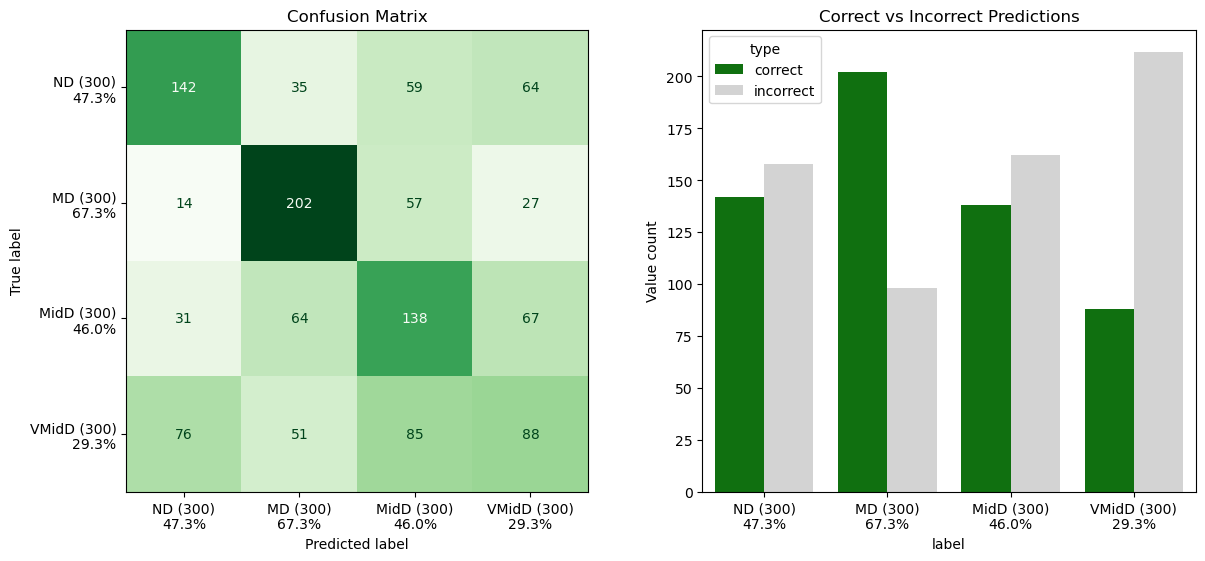

Comparison dataset results
Global accuracy : 0.5211


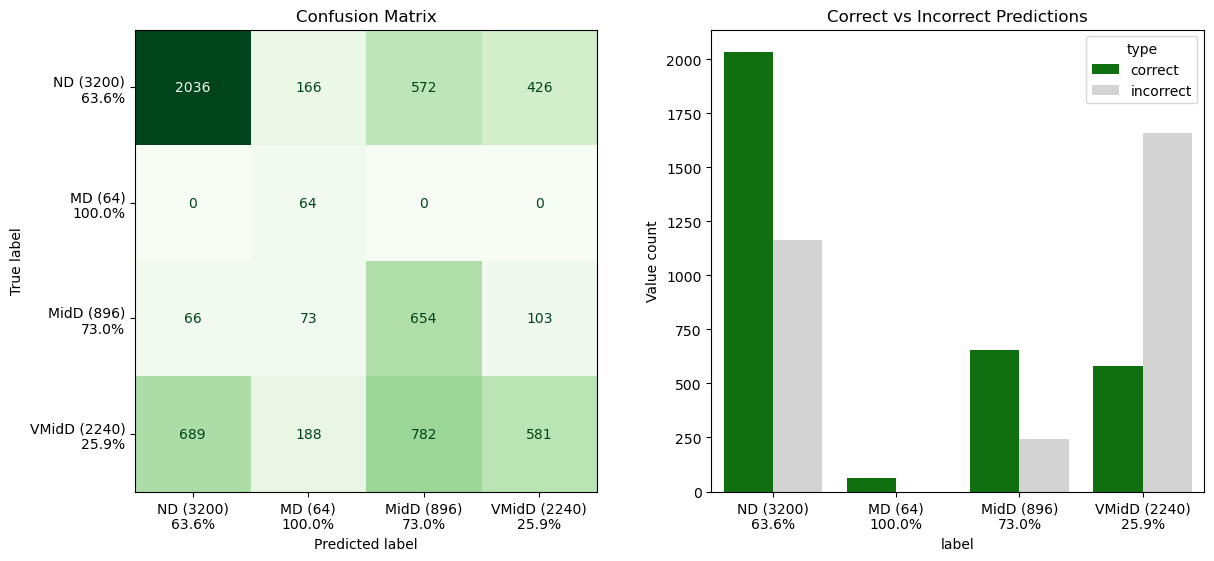

In [44]:
print("Main dataset test results")
print(f"Global accuracy : {accuracy_score(Y_test, Y_test_pred):.4f}")
show_graph(Y_test, Y_test_pred)

print("Comparison dataset results")
print(f"Global accuracy : {accuracy_score(Y_comp, Y_comp_pred):.4f}")
show_graph(Y_comp, Y_comp_pred)

# MLP

A multilayer perceptron is introduced to test a neural-network-based model on the same flattened image data.

Even though this notebook does not use a deep CNN architecture, the MLP is still useful as a comparison point because it can model non-linear relationships between features.

## Tuning Hyperparameters for MLP

A tuning phase was also carried out beforehand for the MLP.

### Selected configuration

- `activation = 'tanh'`
- `hidden_layer_sizes = (10, 30, 10)`

## Launch MLP

In [45]:
mlp = MLPClassifier(activation='tanh', hidden_layer_sizes=(10, 30, 10), random_state=RANDOM_STATE)

mlp.fit(X_train_scaled, Y_train)

Y_test_pred, Y_comp_pred = evaluate_overfitting(mlp, X_train_scaled, Y_train, X_test_scaled, Y_test, X_comp_scaled, Y_comp, "MLP")


MLP | Accuracy (ideally close to 1) :
Training accuracy : 0.2503
Internal test accuracy : 0.2500
Comparison dataset accuracy : 0.1400

MLP | Mean Squared Error (ideally close to 0) :
Training MSE : 1.4961
Internal test MSE : 1.5000
Comparison dataset MSE : 2.3600

MLP | Overfitting (ideally close to 0) :
Gap between train and internal test : 0.0003
Gap between train and comparison dataset : 0.1103

MLP | F1-score (ideally close to 1) :
Internal test Macro F1 : 0.1000
Comparison dataset Macro F1 : 0.0614


## Graph Visualization

Main dataset test results
Global accuracy : 0.2500


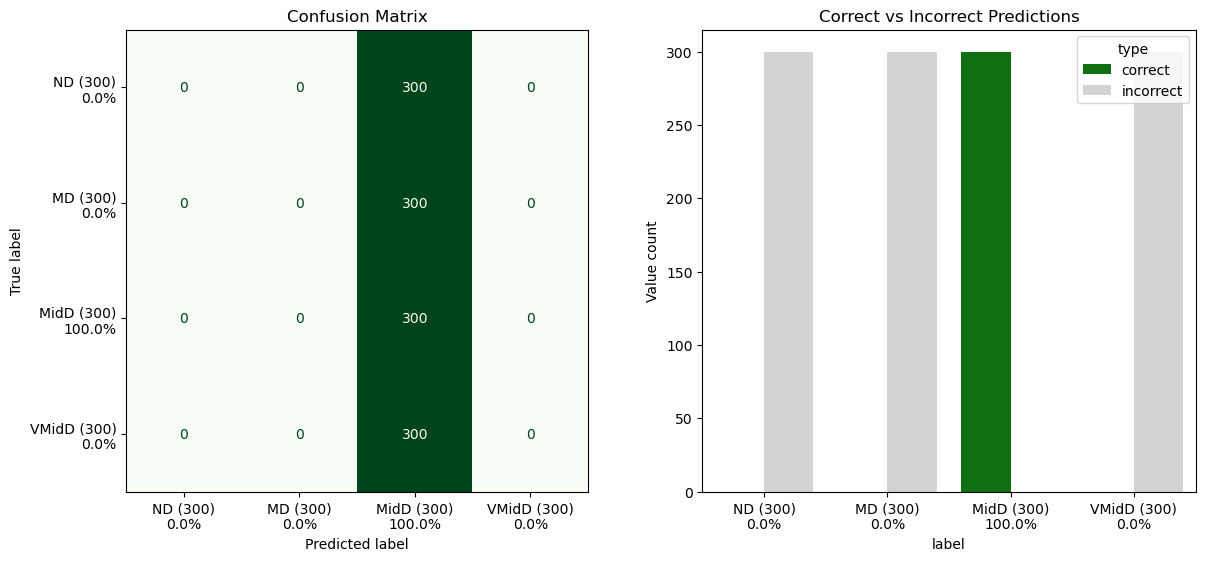

Comparison dataset results
Global accuracy : 0.1400


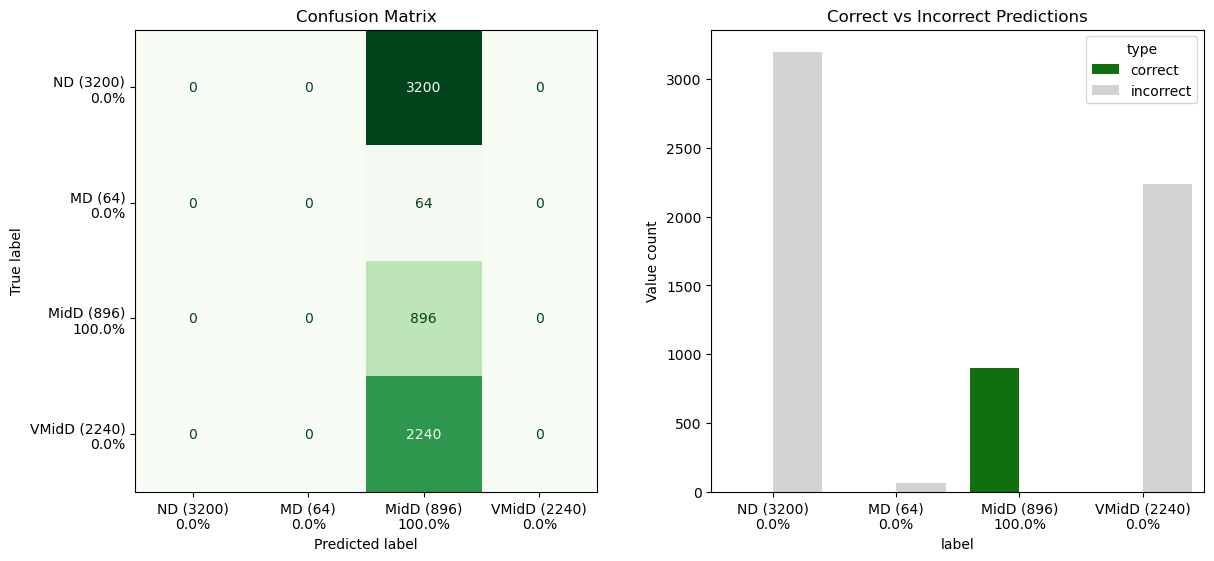

In [46]:
print("Main dataset test results")
print(f"Global accuracy : {accuracy_score(Y_test, Y_test_pred):.4f}")
show_graph(Y_test, Y_test_pred)

print("Comparison dataset results")
print(f"Global accuracy : {accuracy_score(Y_comp, Y_comp_pred):.4f}")
show_graph(Y_comp, Y_comp_pred)

## Conclusion

Overall, the **best model was LinearSVC**. It gave the most convincing results and generalized better than the other models. However, it was also the slowest one, mainly because `max_iter = 10000`, with a runtime of about **1 hour**, while the other models only needed a few seconds or minutes. This shows that the most efficient model is not always the fastest one.

The **worst model was MLP**, which performed very poorly and failed to classify the images correctly. This suggests that a simple neural network is not well suited here.

In the context of our project, these results show that classical machine learning models can already provide useful results, but they also have clear limits for medical image classification. The notebook highlights both the strengths and weaknesses of our approach, and shows that **LinearSVC is the best compromise in this experiment**. For future work, it would be interesting to test models more adapted to images, or use larger dataset and train theme on models for hours or days.
